**End-to-End Machine Learning Project:**

Customer Churn Prediction Machine Learning Model

Saliha Askin Sonmez


In [2]:
# Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(42)

In [3]:
# Load dataset

df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Cleaning
# Drop columns that do not help prediction

df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

X = df.drop(columns=["Exited"])
y = df["Exited"]

categorical_features = ["Geography", "Gender"]
numeric_features = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember",
    "EstimatedSalary"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

**Explanatory Data Analysis**

To better understand the data, I visualized and compared some of the important variables.


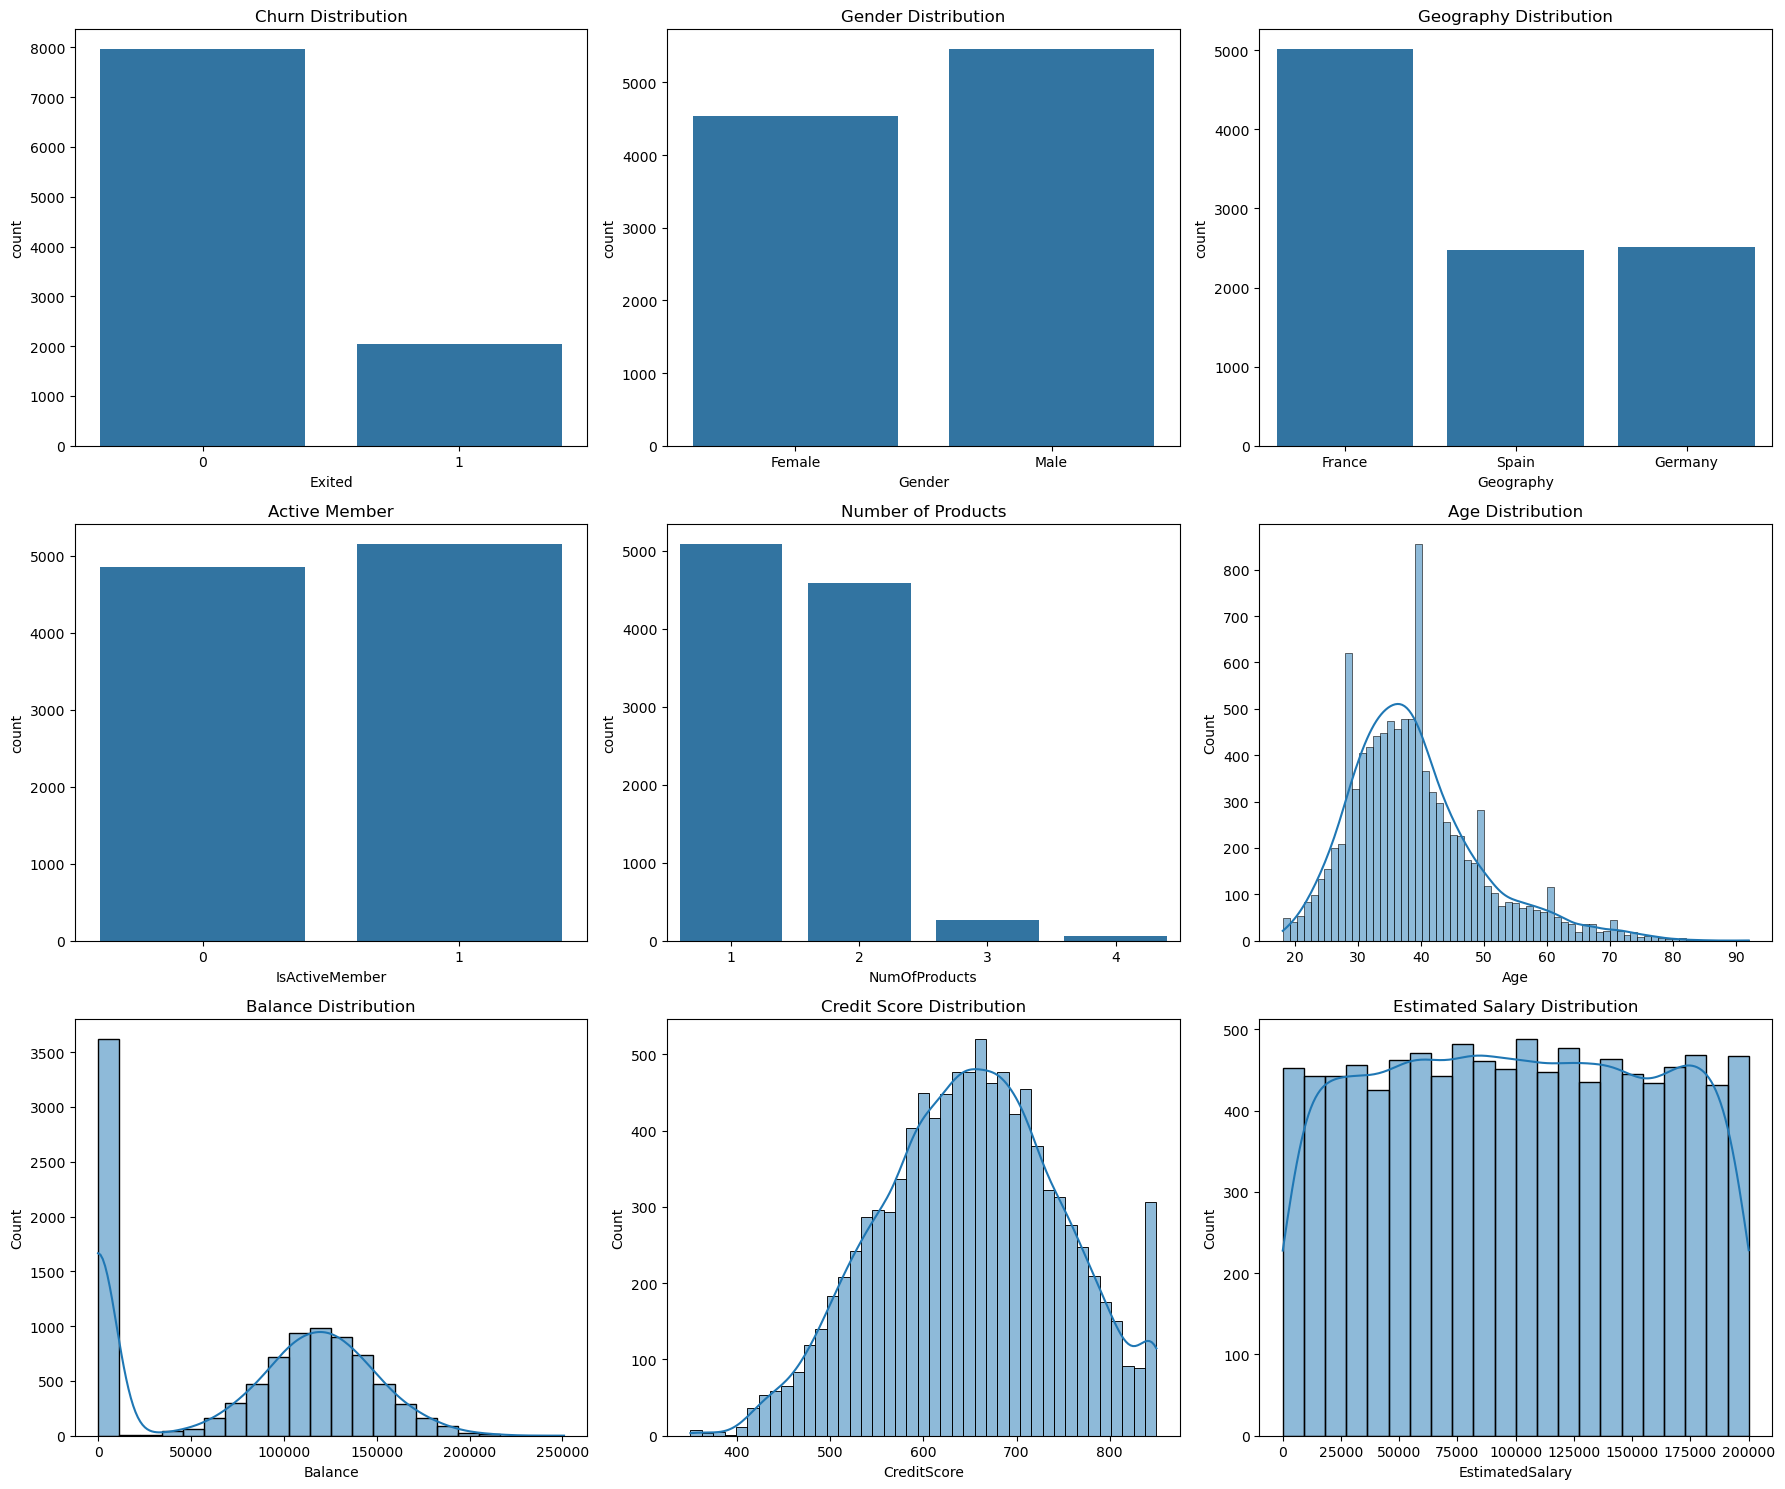

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# --- Categorical Variables ---

# 1. Target
sns.countplot(x="Exited", data=df, ax=axes[0,0])
axes[0,0].set_title("Churn Distribution")

# 2. Gender
sns.countplot(x="Gender", data=df, ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

# 3. Geography
sns.countplot(x="Geography", data=df, ax=axes[0,2])
axes[0,2].set_title("Geography Distribution")

# 4. Active Member
sns.countplot(x="IsActiveMember", data=df, ax=axes[1,0])
axes[1,0].set_title("Active Member")

# 5. Number of Products
sns.countplot(x="NumOfProducts", data=df, ax=axes[1,1])
axes[1,1].set_title("Number of Products")

# --- Numerical Variables ---

# 6. Age
sns.histplot(df["Age"], kde=True, ax=axes[1,2])
axes[1,2].set_title("Age Distribution")

# 7. Balance
sns.histplot(df["Balance"], kde=True, ax=axes[2,0])
axes[2,0].set_title("Balance Distribution")

# 8. Credit Score
sns.histplot(df["CreditScore"], kde=True, ax=axes[2,1])
axes[2,1].set_title("Credit Score Distribution")

# 9. Estimated Salary
sns.histplot(df["EstimatedSalary"], kde=True, ax=axes[2,2])
axes[2,2].set_title("Estimated Salary Distribution")

plt.tight_layout()
plt.show()

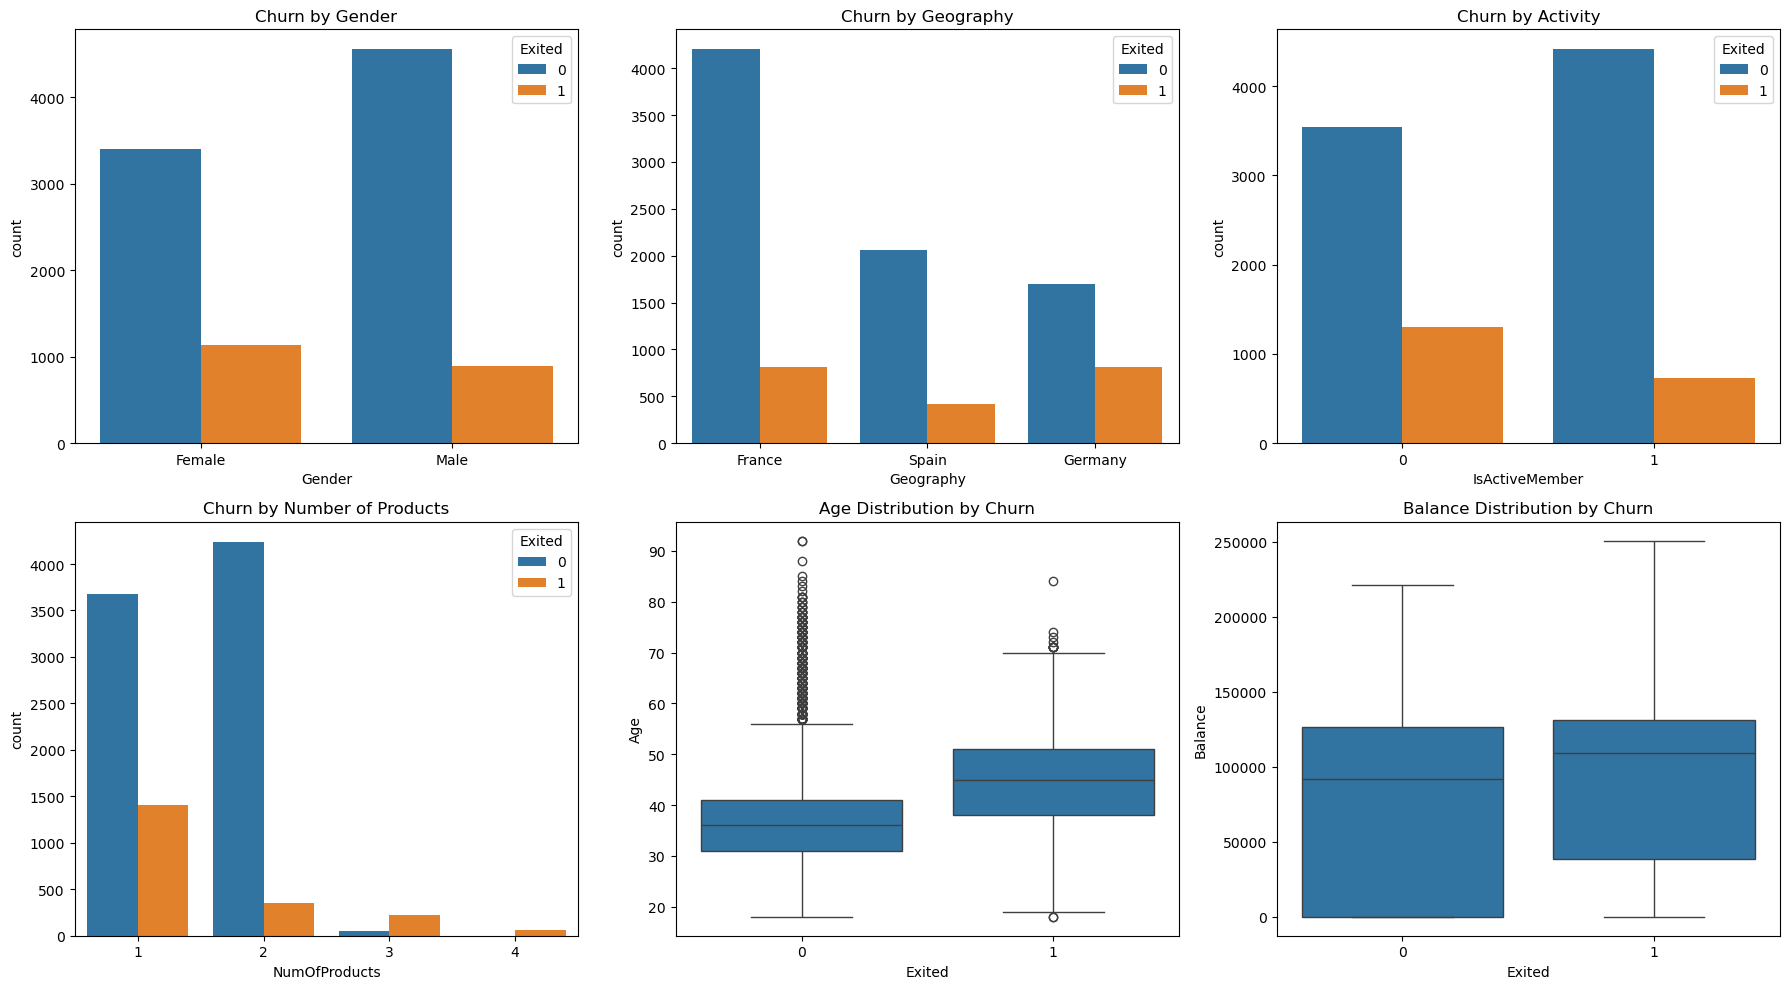

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gender vs Churn
sns.countplot(x="Gender", hue="Exited", data=df, ax=axes[0,0])
axes[0,0].set_title("Churn by Gender")

# 2. Geography vs Churn
sns.countplot(x="Geography", hue="Exited", data=df, ax=axes[0,1])
axes[0,1].set_title("Churn by Geography")

# 3. Active Member vs Churn
sns.countplot(x="IsActiveMember", hue="Exited", data=df, ax=axes[0,2])
axes[0,2].set_title("Churn by Activity")

# 4. Num of Products vs Churn
sns.countplot(x="NumOfProducts", hue="Exited", data=df, ax=axes[1,0])
axes[1,0].set_title("Churn by Number of Products")

# 5. Age vs Churn
sns.boxplot(x="Exited", y="Age", data=df, ax=axes[1,1])
axes[1,1].set_title("Age Distribution by Churn")

# 6. Balance vs Churn
sns.boxplot(x="Exited", y="Balance", data=df, ax=axes[1,2])
axes[1,2].set_title("Balance Distribution by Churn")

plt.tight_layout()
plt.show()

In [7]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

Train size: (8000, 10)
Test size: (2000, 10)
Churn rate in train: 0.204
Churn rate in test: 0.204


In [8]:
# Function to evaluate classification models

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("-" * 50)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"ROC AUC:   {roc_auc:.3f}")

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve — {name}")
    plt.show()

    return {
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "ROC_AUC": roc_auc
    }

1-Logistic Regression

Best Logistic Regression Parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV ROC AUC: 0.766

Logistic Regression
--------------------------------------------------
Confusion Matrix:
[[1142  451]
 [ 122  285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

Precision: 0.387
Recall:    0.700
ROC AUC:   0.777


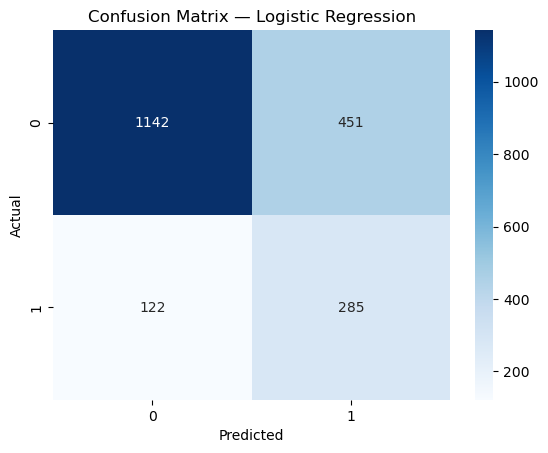

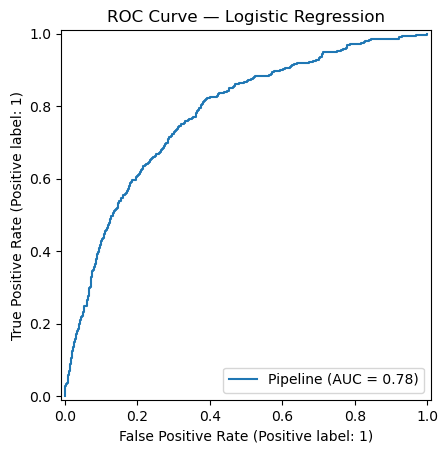

In [9]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline,
    log_reg_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)
print("Best CV ROC AUC:", log_reg_grid.best_score_.round(3))

log_reg_result = evaluate_model(
    "Logistic Regression",
    log_reg_grid.best_estimator_,
    X_test,
    y_test
)

2-Random Forest

Best Random Forest Parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV ROC AUC: 0.861

Random Forest
--------------------------------------------------
Confusion Matrix:
[[1359  234]
 [ 116  291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.55      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.82      0.83      2000

Precision: 0.554
Recall:    0.715
ROC AUC:   0.866


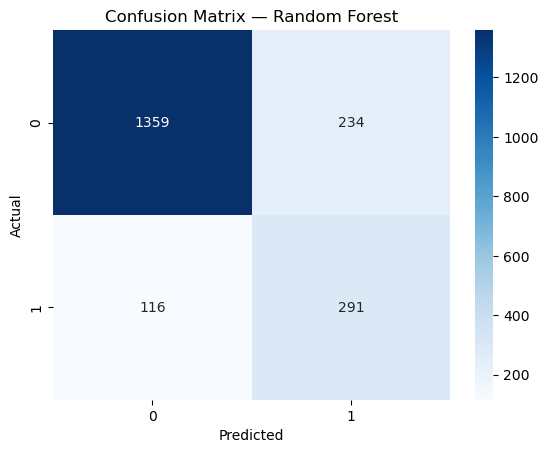

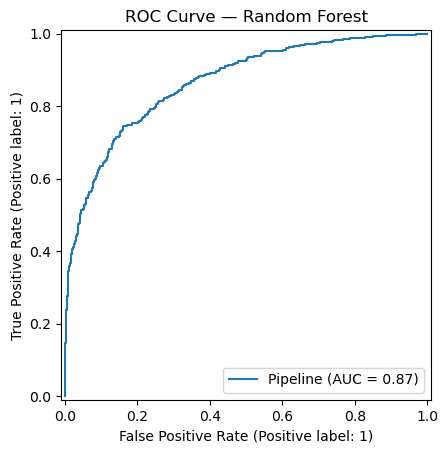

In [10]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best CV ROC AUC:", rf_grid.best_score_.round(3))

rf_result = evaluate_model(
    "Random Forest",
    rf_grid.best_estimator_,
    X_test,
    y_test
)

3-Xgboost

Best XGBoost Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC AUC: 0.866

XGBoost
--------------------------------------------------
Confusion Matrix:
[[1544   49]
 [ 210  197]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

Precision: 0.801
Recall:    0.484
ROC AUC:   0.871


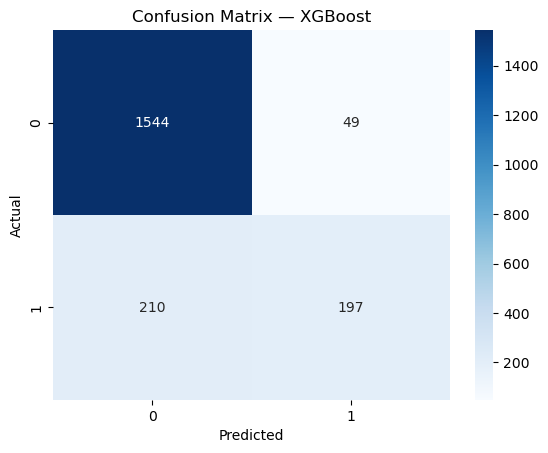

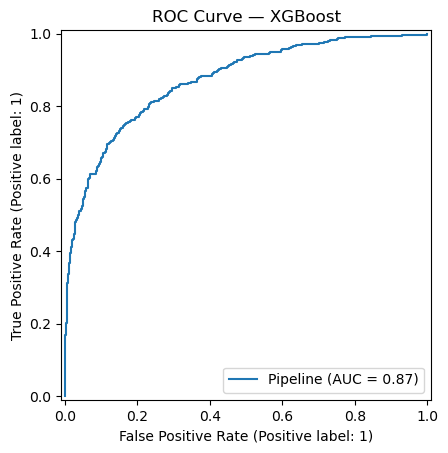

In [11]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)
print("Best CV ROC AUC:", xgb_grid.best_score_.round(3))

xgb_result = evaluate_model(
    "XGBoost",
    xgb_grid.best_estimator_,
    X_test,
    y_test
)

Model Comparison

In [12]:
results = pd.DataFrame([
    log_reg_result,
    rf_result,
    xgb_result
])

results.sort_values("ROC_AUC", ascending=False)

,Model,Precision,Recall,ROC_AUC
2,XGBoost,0.800813,0.484029,0.871267
1,Random Forest,0.554286,0.714988,0.865940
0,Logistic Regression,0.387228,0.700246,0.777349


**Model Performance & Business Interpretation**

XGBoost achieved the highest ROC AUC (0.87) and precision (0.80), indicating strong overall performance and fewer false positives. However, its recall is low (0.48), meaning it misses a large portion of actual churners (210 false negatives).

Random Forest provides a better balance, with higher recall (0.71) and a strong ROC AUC (0.86). It correctly identifies more churners (291 true positives) and significantly reduces false negatives (116) compared to XGBoost.

Logistic Regression has relatively high recall (0.70) but very low precision (0.39), resulting in many false positives (451), making it inefficient due to unnecessary retention efforts.

From a business perspective, recall is the most critical metric in churn prediction.

False negatives are very costly because they represent customers who leave without intervention, leading to direct revenue loss.
False positives also have a cost, as the company may spend resources on customers who would not have churned, but this cost is typically lower than losing a customer.

Although XGBoost is the best model based on ROC AUC and precision, it fails to capture enough churners. Therefore, we can continue with Random Forest model, as it identifies significantly more at-risk customers and reduces potential revenue loss.

                   Feature  Importance
1                 num__Age    0.361590
4       num__NumOfProducts    0.248235
3             num__Balance    0.102775
6      num__IsActiveMember    0.063923
8   cat__Geography_Germany    0.062340
7     num__EstimatedSalary    0.049570
0         num__CreditScore    0.049143
2              num__Tenure    0.026159
10        cat__Gender_Male    0.023118
9     cat__Geography_Spain    0.007080


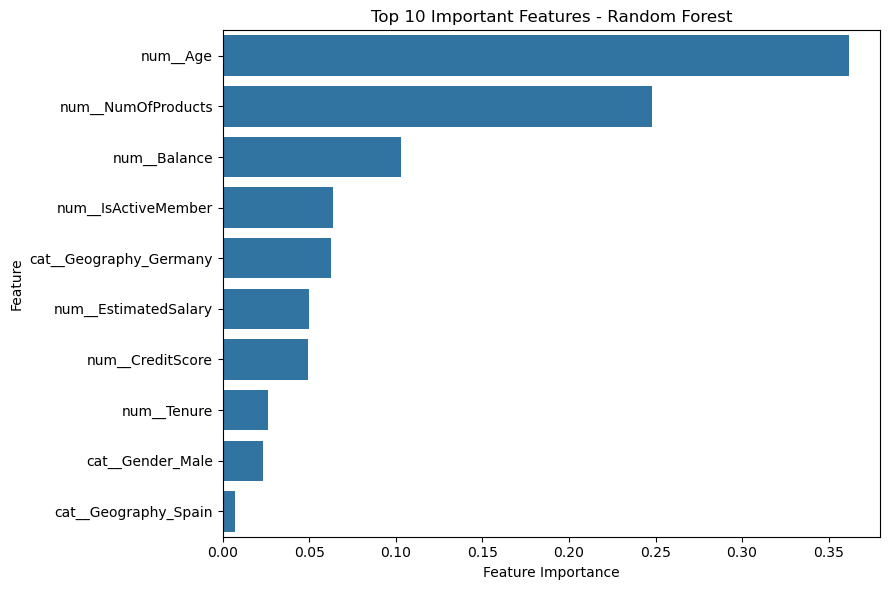

In [13]:

# Best Random Forest model
best_rf = rf_grid.best_estimator_

# Get feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values
importances = best_rf.named_steps["model"].feature_importances_

# Create feature importance dataframe
rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top 10 important features
top_rf_features = rf_feature_importance.head(10)

print(top_rf_features)

# Plot top 10 features
plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Random Forest Feature Importance:
            Feature  RF_Importance
1               Age       0.361590
4     NumOfProducts       0.248235
3           Balance       0.102775
6    IsActiveMember       0.063923
8           Germany       0.062340
7   EstimatedSalary       0.049570
0       CreditScore       0.049143
2            Tenure       0.026159
10      Gender_Male       0.023118
9             Spain       0.007080


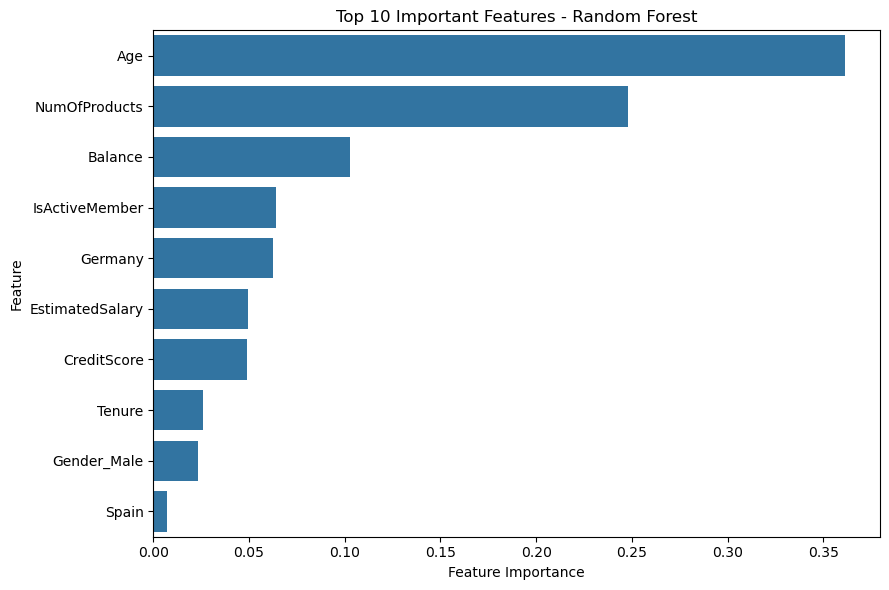


Permutation Importance:
           Feature  Permutation_Importance_Mean  Permutation_Importance_STD
3              Age                     0.126294                    0.005569
6    NumOfProducts                     0.106320                    0.009734
8   IsActiveMember                     0.030699                    0.003789
5          Balance                     0.030542                    0.005004
1        Geography                     0.019407                    0.001564
2           Gender                     0.007027                    0.001446
0      CreditScore                    -0.000085                    0.000558
7        HasCrCard                    -0.000120                    0.000355
9  EstimatedSalary                    -0.000731                    0.001073
4           Tenure                    -0.000883                    0.000726


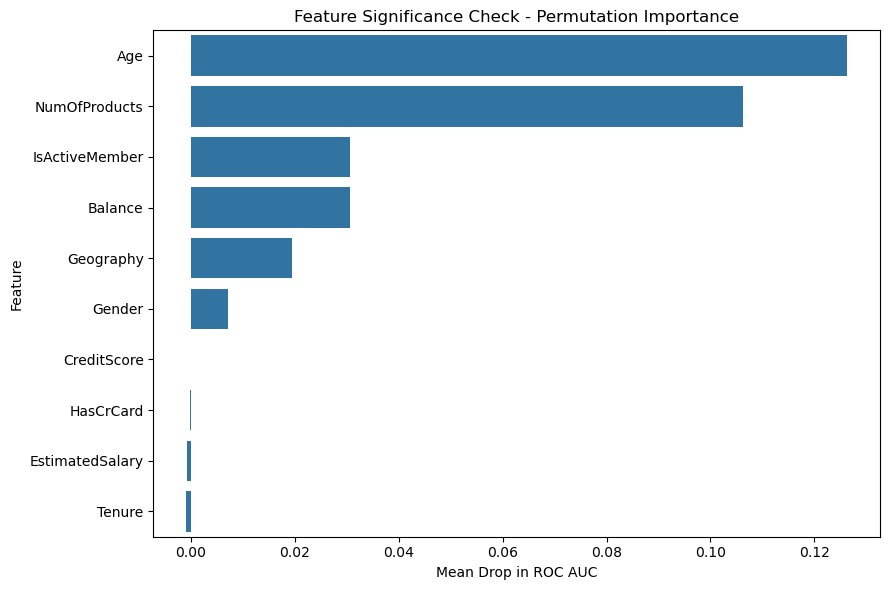

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance

# Best Random Forest pipeline
best_rf = rf_grid.best_estimator_


#  Random Forest Feature Importance

# Feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# RF feature importance
rf_importances = best_rf.named_steps["model"].feature_importances_

rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_importances
})

rf_feature_importance["Feature"] = rf_feature_importance["Feature"] \
    .str.replace("num__", "", regex=False) \
    .str.replace("cat__", "", regex=False) \
    .str.replace("Geography_", "", regex=False)

rf_feature_importance = rf_feature_importance.sort_values(
    by="RF_Importance",
    ascending=False
)

top_rf_features = rf_feature_importance.head(10)

print("Random Forest Feature Importance:")
print(top_rf_features)


plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_rf_features,
    x="RF_Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



# Permutation Importance

perm_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_STD": perm_result.importances_std
}).sort_values(
    by="Permutation_Importance_Mean",
    ascending=False
)

print("\nPermutation Importance:")
print(perm_importance)


plt.figure(figsize=(9, 6))
sns.barplot(
    data=perm_importance,
    x="Permutation_Importance_Mean",
    y="Feature"
)

plt.title("Feature Significance Check - Permutation Importance")
plt.xlabel("Mean Drop in ROC AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()